# Multicollinearity analysis

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [30]:
# Show all rows and columns without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [23]:
df = pd.read_csv("../Intermediate/09_combined_dataset.csv")
df.head()

,time,month,weekend,cell_start,cell_end,ride_count,pay_1250_or_less_start,early_start_jobs_start,entertainment_jobs_start,pay_over_3333_start,...,park_name_start,has_park_end,park_name_end,res_lots_start,com_lots_start,manf_lots_start,res_lots_end,com_lots_end,manf_lots_end,grid_distance
0,early_morning,10,False,892a1001203ffff,892a100aaabffff,2,0.178010,0.207679,0.185864,0.569808,...,NaN,1.0,Highbridge Park,75.0,20.0,1.0,94.0,0.0,0.0,20.0
1,early_morning,10,False,892a1001207ffff,892a10012abffff,1,0.055085,0.495763,0.110169,0.758475,...,NaN,1.0,Mosholu Parkway,167.0,0.0,0.0,92.0,0.0,0.0,1.0
2,early_morning,10,False,892a1001207ffff,892a100a1b3ffff,1,0.055085,0.495763,0.110169,0.758475,...,NaN,NaN,NaN,167.0,0.0,0.0,81.0,2.0,5.0,5.0
3,early_morning,10,False,892a100120fffff,892a1001207ffff,2,0.272167,0.084975,0.263547,0.448276,...,NaN,NaN,NaN,83.0,0.0,3.0,167.0,0.0,0.0,1.0
4,early_morning,10,False,892a100120fffff,892a100120bffff,3,0.272167,0.084975,0.263547,0.448276,...,NaN,1.0,Harris Park,83.0,0.0,3.0,5.0,1.0,2.0,1.0


In [33]:
# Check shape, dtypes, and missing values
print("DataFrame Shape:", df.shape)
print("DataFrame DTypes:")
print(df.dtypes)
print("Missing Values:")
print(df.isnull().sum())

DataFrame Shape: (17987952, 65)
DataFrame DTypes:
time                            str
month                         int64
weekend                        bool
cell_start                      str
cell_end                        str
ride_count                    int64
pay_1250_or_less_start      float64
early_start_jobs_start      float64
entertainment_jobs_start    float64
pay_over_3333_start         float64
age_29_or_younger_start     float64
white_collar_jobs_start     float64
pay_1251_to_3333_start      float64
sex_female_start            float64
job_ct_start                float64
all_day_jobs_start          float64
pay_1250_or_less_end        float64
early_start_jobs_end        float64
entertainment_jobs_end      float64
pay_over_3333_end           float64
age_29_or_younger_end       float64
white_collar_jobs_end       float64
pay_1251_to_3333_end        float64
sex_female_end              float64
job_ct_end                  float64
all_day_jobs_end            float64
total_pop_star

In [34]:
# Check if NaN in park/school columns means "absence" rather than missing data
# by comparing with has_park flag
print(df[['has_park_start', 'park_name_start']].drop_duplicates().head(20))

      has_park_start        park_name_start
0                NaN                    NaN
17               1.0         St. James Park
22               1.0      Washington's Walk
29               1.0        Mosholu Parkway
34               1.0     Van Cortlandt Park
67               1.0         Riverside Park
122              1.0         Broadway Malls
322              1.0           Central Park
528              1.0      Park Avenue Malls
544              1.0       Carl Schurz Park
591              1.0   Riverside Park South
866              1.0       Morningside Park
955              1.0      St. Nicholas Park
1237             1.0     Wagner Houses Pool
1246             1.0     Marcus Garvey Park
1267             1.0      Harlem River Park
1318             1.0  Thomas Jefferson Park
1321             1.0        East River Walk
1389             1.0       Inwood Hill Park
1391             1.0        Fort Tryon Park


In [35]:
# Check if NaN in school columns also means "no school of this type" 
# by checking rows where all school_start columns are NaN
school_cols_start = ['High school_start', 'Secondary School_start', 'early_schooling_start',
                      'elementary_school_start', 'k_12_school_start', 'k_8_school_start',
                      'middle_school_start', 'ungraded_school_start']

print(df[school_cols_start].notnull().sum(axis=1).value_counts())

0    11674071
8     6313881
Name: count, dtype: int64


In [36]:
# Columns where NaN means "absence of feature"
# Convert to boolean flags: 1 if present, 0 if NaN
presence_cols = school_cols_start + [
    'High school_end', 'Secondary School_end', 'early_schooling_end',
    'elementary_school_end', 'k_12_school_end', 'k_8_school_end',
    'middle_school_end', 'ungraded_school_end',
    'on_street_start', 'protected_lane_start',
    'on_street_end', 'protected_lane_end'
]

for col in presence_cols:
    df[col] = df[col].notnull().astype(int)

# has_park is already a 1/NaN flag, just fill NaN with 0
df[['has_park_start', 'has_park_end']] = df[['has_park_start', 'has_park_end']].fillna(0).astype(int)

# Recheck missing values after conversion
print(df.isnull().sum().sort_values(ascending=False).head(20))

park_name_end               15961467
park_name_start             15945205
pay_1250_or_less_end            3139
all_day_jobs_end                3139
job_ct_end                      3139
sex_female_end                  3139
pay_1251_to_3333_end            3139
white_collar_jobs_end           3139
age_29_or_younger_end           3139
pay_over_3333_end               3139
early_start_jobs_end            3139
entertainment_jobs_end          3139
com_lots_end                    2526
res_lots_end                    2526
manf_lots_end                   2526
age_15_to_34_end                2525
female_pop_end                  2525
total_pop_end                   2525
housing_units_end               2525
entertainment_jobs_start         496
dtype: int64


In [37]:
# Drop park_name columns - not needed for regression, has_park flag is enough
df = df.drop(columns=['park_name_start', 'park_name_end'])

# Drop remaining rows with NaN (small fraction of demographic/job/zoning data)
print(f"Rows before dropping: {len(df)}")
df = df.dropna()
print(f"Rows after dropping: {len(df)}")

Rows before dropping: 17987952
Rows after dropping: 17984467


In [38]:
# Compute correlation matrix for numeric feature columns
# Exclude identifier/categorical columns
exclude_cols = ['time', 'cell_start', 'cell_end', 'ride_count']
numeric_cols = [c for c in df.columns if c not in exclude_cols]

corr_matrix = df[numeric_cols].corr()

# Show pairs with high correlation (|corr| > 0.8), excluding self-correlation
high_corr = corr_matrix.where(
    (abs(corr_matrix) > 0.8) & (corr_matrix != 1.0)
)
high_corr_pairs = high_corr.stack().reset_index()
high_corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['feature_1'] < high_corr_pairs['feature_2']]
high_corr_pairs = high_corr_pairs.sort_values('correlation', ascending=False)

print(high_corr_pairs)

                     feature_1                 feature_2  correlation
1438       housing_units_start           total_pop_start     0.930758
1678         housing_units_end             total_pop_end     0.930722
723       pay_1250_or_less_end         pay_over_3333_end    -0.832138
123     pay_1250_or_less_start       pay_over_3333_start    -0.832209
477     pay_1251_to_3333_start       pay_over_3333_start    -0.921196
1077      pay_1251_to_3333_end         pay_over_3333_end    -0.921679
1                        month                   weekend          NaN
2                        month    pay_1250_or_less_start          NaN
5                        month       pay_over_3333_start          NaN
7                        month   white_collar_jobs_start          NaN
8                        month    pay_1251_to_3333_start          NaN
9                        month          sex_female_start          NaN
12                       month      pay_1250_or_less_end          NaN
15                  

In [39]:
df["time"].unique()

<ArrowStringArray>
['early_morning', 'morning', 'midday', 'evening', 'night']
Length: 5, dtype: str

In [ ]:
# Columns to exclude from feature set
BASE_EXCLUDE = [
    'ride_count', 'time', 'month', 'weekend',
    'cell_start', 'cell_end', 'park_name_start', 'park_name_end', 'grid_distance'
]
# Explicit columns to remove per user request
REQUESTED_REMOVE = [
    'pay_1251_to_3333_start', 'pay_1251_to_3333_end',
    'total_pop_start', 'total_pop_end'
]

In [22]:
df_local[BASE_EXCLUDE + REQUESTED_REMOVE].head()

,ride_count,time,month,weekend,cell_start,cell_end,park_name_start,park_name_end,grid_distance,pay_1251_to_3333_start,pay_1251_to_3333_end,total_pop_start,total_pop_end
0,2,early_morning,10,False,892a1001203ffff,892a100aaabffff,NaN,Highbridge Park,20.0,0.252182,0.287625,296.560000,826.473684
1,1,early_morning,10,False,892a1001207ffff,892a10012abffff,NaN,Mosholu Parkway,1.0,0.186441,0.303351,536.866667,368.294118
2,1,early_morning,10,False,892a1001207ffff,892a100a1b3ffff,NaN,NaN,5.0,0.186441,0.358031,536.866667,519.777778
3,2,early_morning,10,False,892a100120fffff,892a1001207ffff,NaN,NaN,1.0,0.279557,0.186441,432.550000,536.866667
4,3,early_morning,10,False,892a100120fffff,892a100120bffff,NaN,Harris Park,1.0,0.279557,0.211092,432.550000,0.000000


Numeric features analyzed: 1, rows used after dropna: 50


/Users/victoria/Projects/HYS_nyc_transit_analysis/venv/lib/python3.14/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/Users/victoria/Projects/HYS_nyc_transit_analysis/venv/lib/python3.14/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


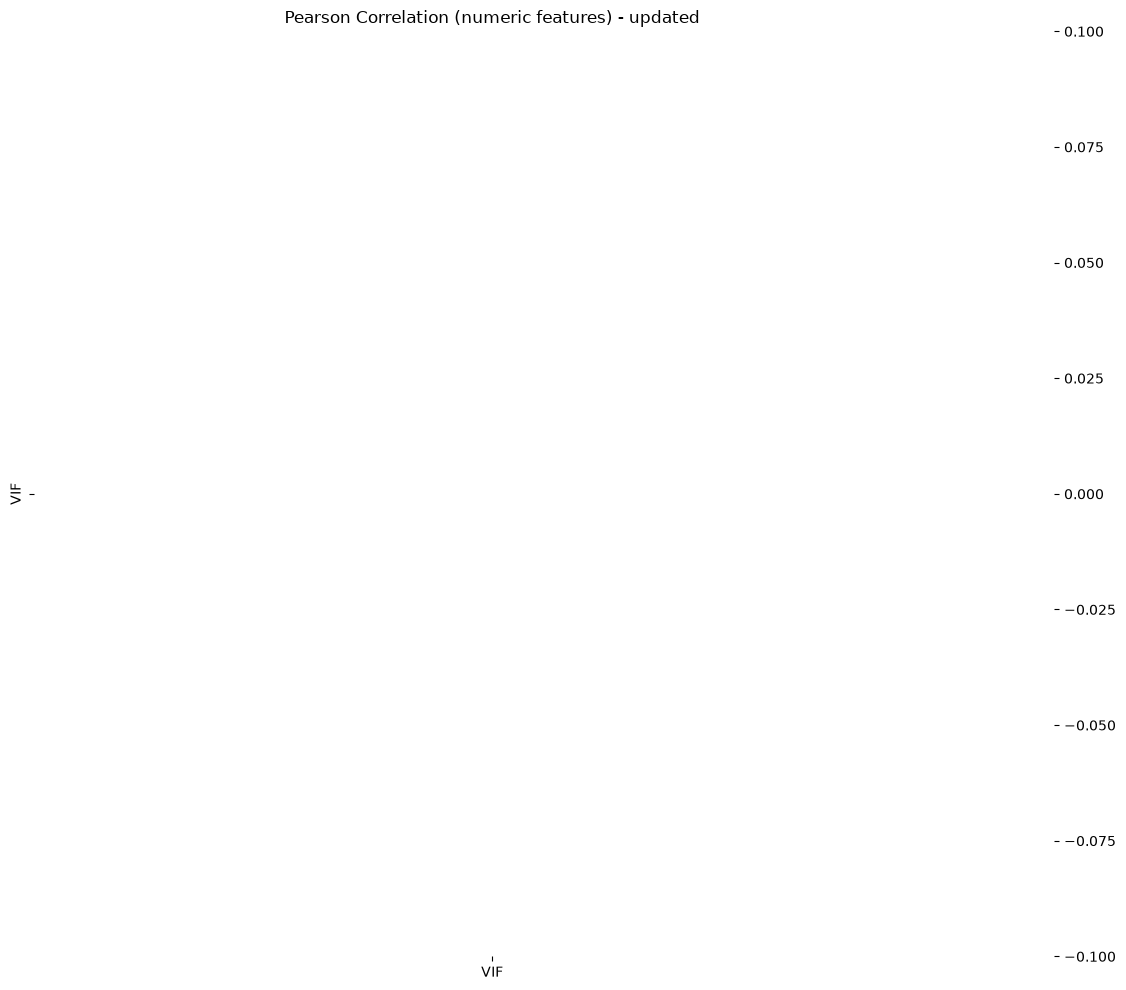

Heatmap saved to /Users/victoria/Projects/HYS_nyc_transit_analysis/test/../Output/correlation_heatmap_notebook_updated.png

High-correlation pairs (|r| > 0.8):
 - None

Top VIF values:
feature  VIF
    VIF  NaN
VIF table saved to /Users/victoria/Projects/HYS_nyc_transit_analysis/test/../Output/vif_notebook_updated.csv

Features with VIF > 10:
 - None

Columns removed by this cleanup:

Suggested features to drop or combine (heuristic):
 - None


In [ ]:


# Track dropped columns
removed_columns = []

# Drop the requested columns if present
for c in REQUESTED_REMOVE:
    if c in df_local.columns:
        df_local = df_local.drop(columns=[c])
        removed_columns.append(c)

# Prefer housing_units over total_pop if housing exists
for side in ['start', 'end']:
    total_col = f'total_pop_{side}'
    housing_col = f'housing_units_{side}'
    if housing_col in df_local.columns and total_col in df_local.columns:
        df_local = df_local.drop(columns=[total_col])
        removed_columns.append(total_col)

# Check job subcategories and drop one per side if they sum to job_ct
job_subcats = ['early_start_jobs', 'all_day_jobs', 'entertainment_jobs', 'white_collar_jobs']
for side in ['start', 'end']:
    subcols = [f'{s}_{side}' for s in job_subcats]
    job_ct_col = f'job_ct_{side}'
    present_subs = [c for c in subcols if c in df_local.columns]
    if job_ct_col in df_local.columns and len(present_subs) == len(job_subcats):
        # compute rows where none of these are null
        tmp = df_local[[job_ct_col] + present_subs].dropna()
        if not tmp.empty:
            sum_subs = tmp[present_subs].sum(axis=1)
            diff = (sum_subs - tmp[job_ct_col]).abs()
            if diff.max() <= 1e-6 or diff.max() <= 1:  # allow tiny rounding
                # subcategories sum to job_ct: choose smallest-mean subcat as 'remainder' to drop
                means = df_local[present_subs].mean()
                drop_col = means.idxmin()
                df_local = df_local.drop(columns=[drop_col])
                removed_columns.append(drop_col)

# Now prepare numeric features for correlation/VIF
df_work = df_local.drop(columns=[c for c in BASE_EXCLUDE if c in df_local.columns], errors='ignore')
df_num = df_work.select_dtypes(include=[np.number]).copy()

# Drop fully-constant columns
const_cols = [c for c in df_num.columns if df_num[c].nunique(dropna=True) <= 1]
if const_cols:
    df_num = df_num.drop(columns=const_cols)
    removed_columns.extend(const_cols)

# Drop rows with NA for stable calculations
df_num_clean = df_num.dropna()
print(f'Numeric features analyzed: {len(df_num.columns)}, rows used after dropna: {df_num_clean.shape[0]}')

# Pearson correlation matrix
corr = df_num_clean.corr(method='pearson')

# Plot heatmap inline and save
out_dir = os.path.join(os.path.dirname(os.path.dirname(os.path.abspath('.'))), 'Output')
if not os.path.exists(out_dir):
    out_dir = os.path.join(os.getcwd(), '..', 'Output')
os.makedirs(out_dir, exist_ok=True)

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='vlag', center=0, annot=False)
plt.title('Pearson Correlation (numeric features) - updated')
plt.tight_layout()
heatmap_path = os.path.join(out_dir, 'correlation_heatmap_notebook_updated.png')
plt.savefig(heatmap_path, dpi=200)
plt.show()
print('Heatmap saved to', heatmap_path)

# Highly correlated pairs (|r| > 0.8)
high_corr_pairs = []
cols = corr.columns.tolist()
for i, a in enumerate(cols):
    for j in range(i + 1, len(cols)):
        b = cols[j]
        val = corr.at[a, b]
        if abs(val) > 0.8:
            high_corr_pairs.append((a, b, float(val)))

print('\nHigh-correlation pairs (|r| > 0.8):')
if high_corr_pairs:
    for a, b, val in high_corr_pairs:
        print(f' - {a} <-> {b}  : corr = {val:.3f}')
else:
    print(' - None')

# Compute VIF
X = df_num_clean.copy()

vif_data = []
for i, col in enumerate(X.columns):
    try:
        vif = variance_inflation_factor(X.values, i)
    except Exception:
        vif = np.nan
    vif_data.append((col, float(vif)))

vif_df = pd.DataFrame(vif_data, columns=['feature', 'VIF']).sort_values('VIF', ascending=False)
print('\nTop VIF values:')
print(vif_df.head(20).to_string(index=False))

vif_csv = os.path.join(out_dir, 'vif_notebook_updated.csv')
vif_df.to_csv(vif_csv, index=False)
print('VIF table saved to', vif_csv)

# Features with VIF > 10
high_vif = vif_df[vif_df['VIF'] > 10]
print('\nFeatures with VIF > 10:')
if not high_vif.empty:
    for _, row in high_vif.iterrows():
        print(f" - {row.feature} : VIF = {row.VIF:.3f}")
else:
    print(' - None')

# Suggestions: drop higher-VIF feature from each high-corr pair, plus high-VIF features
vif_map = dict(vif_data)
suggestions = set()
for a, b, val in high_corr_pairs:
    va = vif_map.get(a, 0)
    vb = vif_map.get(b, 0)
    drop = a if va >= vb else b
    suggestions.add(drop)
for f in high_vif['feature'].tolist():
    suggestions.add(f)

print('\nColumns removed by this cleanup:')
for c in sorted(removed_columns):
    print(' -', c)

print('\nSuggested features to drop or combine (heuristic):')
if suggestions:
    for s in sorted(suggestions):
        print(' -', s)
else:
    print(' - None')


In [20]:
df = pd.read_csv("../Output/vif_notebook_updated.csv")
df.head()


,feature,VIF
0,VIF,NaN
